In [3]:
from pathlib import Path

import numpy as np
import pandas as pd


# --------------------------------------------------
# Load CSV
# --------------------------------------------------

INPUT_PATH = Path("sample_data/schools_sample.csv")

REQUIRED_COLUMNS = [
    "school_id",
    "school_name",
    "district",
    "city",
    "state",
    "level",
    "enrollment_2024",
    "latitude",
    "longitude",
]

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {INPUT_PATH}. Upload the CSV before running this cell."
    )

schools = pd.read_csv(INPUT_PATH)
schools.columns = schools.columns.str.strip()

print(f"Loaded {len(schools)} schools.")


# --------------------------------------------------
# Validate CSV structure
# --------------------------------------------------

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(schools.columns))

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")


# --------------------------------------------------
# Clean identifiers and preserve original coordinates
# --------------------------------------------------

schools["school_id"] = schools["school_id"].astype("string").str.strip()
schools["school_name"] = schools["school_name"].astype("string").str.strip()

schools["original_latitude"] = schools["latitude"]
schools["original_longitude"] = schools["longitude"]


# --------------------------------------------------
# Convert coordinates to numeric values
# --------------------------------------------------

# Blank values and nonnumeric text become NaN.
schools["latitude"] = pd.to_numeric(
    schools["latitude"],
    errors="coerce",
)

schools["longitude"] = pd.to_numeric(
    schools["longitude"],
    errors="coerce",
)


# --------------------------------------------------
# Identify potential problems
# --------------------------------------------------

missing_school_id = (
    schools["school_id"].isna()
    | schools["school_id"].eq("")
)

duplicate_school_id = (
    schools["school_id"].notna()
    & schools["school_id"].duplicated(keep=False)
)

missing_school_name = (
    schools["school_name"].isna()
    | schools["school_name"].eq("")
)

missing_latitude = schools["latitude"].isna()
missing_longitude = schools["longitude"].isna()

invalid_latitude = (
    schools["latitude"].notna()
    & (
        ~np.isfinite(schools["latitude"])
        | ~schools["latitude"].between(-90, 90)
    )
)

invalid_longitude = (
    schools["longitude"].notna()
    & (
        ~np.isfinite(schools["longitude"])
        | ~schools["longitude"].between(-180, 180)
    )
)

zero_coordinates = (
    schools["latitude"].eq(0)
    & schools["longitude"].eq(0)
)

# Duplicate coordinates are flagged for review rather than
# automatically treated as errors, since schools can share a campus.
duplicate_coordinates = (
    schools["latitude"].notna()
    & schools["longitude"].notna()
    & schools.duplicated(
        subset=["latitude", "longitude"],
        keep=False,
    )
)


# --------------------------------------------------
# Create one readable validation note per school
# --------------------------------------------------

def build_validation_notes(row_index):
    issues = []

    if missing_school_id.loc[row_index]:
        issues.append("missing school_id")

    if duplicate_school_id.loc[row_index]:
        issues.append("duplicate school_id")

    if missing_school_name.loc[row_index]:
        issues.append("missing school_name")

    if missing_latitude.loc[row_index]:
        issues.append("missing or nonnumeric latitude")
    elif invalid_latitude.loc[row_index]:
        issues.append("latitude outside -90 to 90")

    if missing_longitude.loc[row_index]:
        issues.append("missing or nonnumeric longitude")
    elif invalid_longitude.loc[row_index]:
        issues.append("longitude outside -180 to 180")

    if zero_coordinates.loc[row_index]:
        issues.append("suspicious (0, 0) coordinates")

    if duplicate_coordinates.loc[row_index]:
        issues.append("coordinates shared with another school")

    return "; ".join(issues)


schools["coordinate_validation_notes"] = [
    build_validation_notes(index)
    for index in schools.index
]

schools["coordinate_validation_status"] = np.where(
    schools["coordinate_validation_notes"].eq(""),
    "passed_basic_validation",
    "needs_review",
)


# --------------------------------------------------
# Display validation summary
# --------------------------------------------------

validation_issues = schools.loc[
    schools["coordinate_validation_status"].eq("needs_review"),
    [
        "school_id",
        "school_name",
        "city",
        "state",
        "original_latitude",
        "original_longitude",
        "coordinate_validation_notes",
    ],
]

passed_count = schools["coordinate_validation_status"].eq(
    "passed_basic_validation"
).sum()

print("\nBasic CSV validation complete")
print("--------------------------------")
print(f"Total rows:              {len(schools)}")
print(f"Passed basic validation: {passed_count}")
print(f"Need review:             {len(validation_issues)}")

if len(schools) != 25:
    print(f"Warning: Expected 25 schools, but found {len(schools)}.")

if validation_issues.empty:
    print("\nNo basic CSV or coordinate-format problems found.")
else:
    print("\nRows requiring review:")
    display(validation_issues)

print(
    "\nNote: Passing this check only means that the coordinates are "
    "present and numerically plausible. It does not prove that they "
    "point to the correct school campus."
)

Loaded 25 schools.

Basic CSV validation complete
--------------------------------
Total rows:              25
Passed basic validation: 25
Need review:             0

No basic CSV or coordinate-format problems found.

Note: Passing this check only means that the coordinates are present and numerically plausible. It does not prove that they point to the correct school campus.


In [4]:
import folium
import ipywidgets as widgets

from folium.plugins import Fullscreen, MousePosition
from IPython.display import display, clear_output


# --------------------------------------------------
# Confirm that the validation cell was run
# --------------------------------------------------

if "schools" not in globals():
    raise RuntimeError(
        "The 'schools' DataFrame does not exist. "
        "Run the CSV validation cell first."
    )

if schools.empty:
    raise ValueError("The schools DataFrame is empty.")

required_map_columns = [
    "school_id",
    "school_name",
    "district",
    "city",
    "state",
    "latitude",
    "longitude",
]

missing_map_columns = [
    column
    for column in required_map_columns
    if column not in schools.columns
]

if missing_map_columns:
    raise ValueError(
        f"Missing columns required for mapping: {missing_map_columns}"
    )


# --------------------------------------------------
# Create a dropdown containing all schools
# --------------------------------------------------

school_options = []

for position, (row_index, row) in enumerate(schools.iterrows()):
    label = (
        f"{position + 1}. {row['school_name']} — "
        f"{row['city']}, {row['state']}"
    )
    school_options.append((label, row_index))


school_selector = widgets.Dropdown(
    options=school_options,
    description="Select school:",
    layout=widgets.Layout(width="95%"),
    style={"description_width": "initial"},
)

map_output = widgets.Output()


# --------------------------------------------------
# Create a map for the selected school
# --------------------------------------------------

def display_school_map(change=None):
    row_index = school_selector.value
    school = schools.loc[row_index]

    latitude = float(school["latitude"])
    longitude = float(school["longitude"])

    with map_output:
        clear_output(wait=True)

        print(f"School number: {list(schools.index).index(row_index) + 1}")
        print(f"School ID:     {school['school_id']}")
        print(f"School name:   {school['school_name']}")
        print(f"District:      {school['district']}")
        print(f"City/state:    {school['city']}, {school['state']}")
        print(f"Coordinates:   {latitude:.7f}, {longitude:.7f}")

        print(
            "\nThe red marker represents the coordinate supplied "
            "in the original CSV."
        )
        print(
            "Use the layer control in the upper-right corner to "
            "switch between the street map and reference imagery."
        )

        campus_map = folium.Map(
            location=[latitude, longitude],
            zoom_start=18,
            tiles=None,
            control_scale=True,
        )

        # OpenStreetMap provides roads, labels, and mapped school features.
        folium.TileLayer(
            tiles="OpenStreetMap",
            name="OpenStreetMap — identity reference",
            show=True,
        ).add_to(campus_map)

        # Esri World Imagery is used only as a visual reference.
        # It is not the final reproducible NAIP imagery.
        folium.TileLayer(
            tiles=(
                "https://server.arcgisonline.com/ArcGIS/rest/services/"
                "World_Imagery/MapServer/tile/{z}/{y}/{x}"
            ),
            attr=(
                "Tiles © Esri — Source: Esri, Maxar, Earthstar "
                "Geographics, and the GIS User Community"
            ),
            name="Esri World Imagery — reference only",
            show=False,
        ).add_to(campus_map)

        # Add the supplied coordinate as a red marker.
        popup_text = (
            f"<b>{school['school_name']}</b><br>"
            f"School ID: {school['school_id']}<br>"
            f"Latitude: {latitude:.7f}<br>"
            f"Longitude: {longitude:.7f}<br>"
            f"<br>Supplied CSV coordinate"
        )

        folium.Marker(
            location=[latitude, longitude],
            tooltip="Supplied CSV coordinate",
            popup=folium.Popup(popup_text, max_width=350),
            icon=folium.Icon(
                color="red",
                icon="info-sign",
            ),
        ).add_to(campus_map)

        # Add a 100-meter reference circle around the point.
        folium.Circle(
            location=[latitude, longitude],
            radius=100,
            color="red",
            weight=2,
            fill=False,
            tooltip="100-meter radius around supplied coordinate",
        ).add_to(campus_map)

        # Show latitude and longitude beneath the mouse cursor.
        MousePosition(
            position="bottomright",
            separator=", ",
            prefix="Cursor coordinates:",
            num_digits=7,
        ).add_to(campus_map)

        Fullscreen(
            position="topleft",
            title="Open full screen",
            title_cancel="Exit full screen",
        ).add_to(campus_map)

        folium.LayerControl(
            position="topright",
            collapsed=False,
        ).add_to(campus_map)

        display(campus_map)


# Update the map whenever another school is selected.
school_selector.observe(
    display_school_map,
    names="value",
)

display(school_selector)
display(map_output)

# Display the first school immediately.
display_school_map()

Dropdown(description='Select school:', layout=Layout(width='95%'), options=(('1. Wedowee Middle School — Wedow…

Output()

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd


# --------------------------------------------------
# Initialize every school as confirmed
# --------------------------------------------------

schools["basemap_review_status"] = "confirmed"

schools["basemap_review_notes"] = (
    "Supplied coordinate matches the named school campus."
)

schools["coordinate_evidence"] = (
    "OpenStreetMap; Esri World Imagery; Google Maps manual verification"
)

schools["coordinate_changed"] = False

# For confirmed schools, retain the supplied coordinates.
schools["resolved_latitude"] = schools["latitude"]
schools["resolved_longitude"] = schools["longitude"]


# --------------------------------------------------
# Record the three exceptions
# --------------------------------------------------

manual_results = {
    "Kofa High School": {
        "status": "uncertain",
        "notes": (
            "Available basemap evidence was insufficient or conflicting. "
            "Requires verification using an authoritative school address."
        ),
    },
    "Beverly Hills High": {
        "status": "confirmed_with_offset",
        "notes": (
            "Supplied point is offset from the reference map point but "
            "still corresponds to the correct school campus."
        ),
    },
    "HILLDALE LOWER ES": {
        "status": "confirmed_with_offset",
        "notes": (
            "Supplied point is offset from the reference map point but "
            "still corresponds to the correct school campus."
        ),
    },
}


# Confirm that every named school exists exactly once.
for school_name, result in manual_results.items():
    matching_rows = schools["school_name"].eq(school_name)

    if matching_rows.sum() != 1:
        raise ValueError(
            f"Expected exactly one row for '{school_name}', "
            f"but found {matching_rows.sum()}."
        )

    schools.loc[
        matching_rows,
        "basemap_review_status",
    ] = result["status"]

    schools.loc[
        matching_rows,
        "basemap_review_notes",
    ] = result["notes"]


# --------------------------------------------------
# Do not approve the uncertain coordinate yet
# --------------------------------------------------

uncertain_rows = schools["basemap_review_status"].eq("uncertain")

schools.loc[uncertain_rows, "resolved_latitude"] = np.nan
schools.loc[uncertain_rows, "resolved_longitude"] = np.nan


# --------------------------------------------------
# Record review time
# --------------------------------------------------

schools["basemap_reviewed_utc"] = pd.Timestamp.now(
    tz="UTC"
).isoformat()


# --------------------------------------------------
# Save a new reviewed CSV
# --------------------------------------------------

OUTPUT_PATH = Path("sample_data/schools_basemap_reviewed.csv")
schools.to_csv(OUTPUT_PATH, index=False)


# --------------------------------------------------
# Display a review summary
# --------------------------------------------------

print("Basemap review saved successfully")
print("---------------------------------")
print(f"Output: {OUTPUT_PATH}\n")

print(
    schools["basemap_review_status"]
    .value_counts()
    .to_string()
)

display(
    schools[
        [
            "school_id",
            "school_name",
            "latitude",
            "longitude",
            "basemap_review_status",
            "resolved_latitude",
            "resolved_longitude",
            "basemap_review_notes",
        ]
    ]
)

Basemap review saved successfully
---------------------------------
Output: sample_data/schools_basemap_reviewed.csv

basemap_review_status
confirmed                22
confirmed_with_offset     2
uncertain                 1


,school_id,school_name,latitude,longitude,basemap_review_status,resolved_latitude,resolved_longitude,basemap_review_notes
0,10282001124,Wedowee Middle School,33.313157,-85.495877,confirmed,33.313157,-85.495877,Supplied coordinate matches the named school c...
1,40963000996,Kofa High School,32.674300,-114.636000,uncertain,NaN,NaN,Available basemap evidence was insufficient or...
2,60483000471,Beverly Hills High,34.061692,-118.412181,confirmed_with_offset,34.061692,-118.412181,Supplied point is offset from the reference ma...
3,61734009378,Cerra Vista Elementary,36.829411,-121.372331,confirmed,36.829411,-121.372331,Supplied coordinate matches the named school c...
4,60001909278,Wells Middle,37.711839,-121.918954,confirmed,37.711839,-121.918954,Supplied coordinate matches the named school c...
5,130333001308,Lincoln County Elementary School,33.796652,-82.491780,confirmed,33.796652,-82.491780,Supplied coordinate matches the named school c...
6,160264000465,CLAUDE A WILCOX ELEMENTARY SCHOOL,42.898474,-112.474380,confirmed,42.898474,-112.474380,Supplied coordinate matches the named school c...
7,160000100084,PRIEST RIVER LAMANNA HIGH,48.189478,-116.917391,confirmed,48.189478,-116.917391,Supplied coordinate matches the named school c...
8,180283000341,Zionsville Community High School,39.961100,-86.274000,confirmed,39.961100,-86.274000,Supplied coordinate matches the named school c...
9,240039000683,Bel Air High,39.531077,-76.348008,confirmed,39.531077,-76.348008,Supplied coordinate matches the named school c...


In [6]:
from google.colab import files

files.download("sample_data/schools_basemap_reviewed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
%pip install -q pystac-client planetary-computer rasterio pyproj matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.0 MB/s eta 0:00:00


In [8]:
from pathlib import Path
from IPython.display import display

import hashlib
import json
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import rasterio

from pyproj import CRS, Transformer
from pystac_client import Client
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.vrt import WarpedVRT


# --------------------------------------------------
# Configuration
# --------------------------------------------------

STAC_API_URL = (
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

NAIP_COLLECTION = "naip"

# Initial test size: 800 m × 800 m
TEST_CROP_SIZE_M = 800

# Reject a crop if less than 98% has imagery
MIN_COVERAGE_FRACTION = 0.98

OUTPUT_DIR = Path("outputs/naip_test_crops")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Connect to the searchable NAIP catalog
catalog = Client.open(STAC_API_URL)


# --------------------------------------------------
# Helper functions
# --------------------------------------------------

def safe_filename(text):
    """Convert a school name into a safe filename."""

    return re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        str(text),
    ).strip("_")


def choose_coordinate(school):
    """
    Use the reviewed coordinate when available.

    If the reviewed coordinates are blank, retain the
    original coordinate but explicitly flag its source.
    """

    resolved_latitude = school.get("resolved_latitude")
    resolved_longitude = school.get("resolved_longitude")

    if (
        pd.notna(resolved_latitude)
        and pd.notna(resolved_longitude)
    ):
        return (
            float(resolved_latitude),
            float(resolved_longitude),
            "resolved_coordinate",
        )

    return (
        float(school["latitude"]),
        float(school["longitude"]),
        "original_coordinate_flagged_for_review",
    )


def utm_crs_for_point(latitude, longitude):
    """
    Select the appropriate UTM coordinate system.

    UTM lets us define crop dimensions in metres.
    """

    zone = int((longitude + 180) // 6) + 1

    if latitude >= 0:
        epsg = 32600 + zone
    else:
        epsg = 32700 + zone

    return CRS.from_epsg(epsg)


def get_item_year(item):
    """Extract the acquisition year from a STAC item."""

    date_value = (
        item.properties.get("datetime")
        or item.properties.get("start_datetime")
        or item.properties.get("end_datetime")
    )

    timestamp = pd.to_datetime(
        date_value,
        utc=True,
        errors="coerce",
    )

    if not pd.isna(timestamp):
        return int(timestamp.year)

    year_value = item.properties.get("naip:year")

    if year_value is not None:
        return int(year_value)

    return None


def get_item_datetime(item):
    """Extract a reproducible acquisition timestamp."""

    date_value = (
        item.properties.get("datetime")
        or item.properties.get("start_datetime")
        or item.properties.get("end_datetime")
    )

    timestamp = pd.to_datetime(
        date_value,
        utc=True,
        errors="coerce",
    )

    if pd.isna(timestamp):
        return None

    return timestamp.isoformat()


def calculate_sha256(file_path):
    """Create a checksum for verifying the downloaded file."""

    digest = hashlib.sha256()

    with file_path.open("rb") as file_handle:
        for chunk in iter(
            lambda: file_handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


# --------------------------------------------------
# Read and combine same-year NAIP tiles
# --------------------------------------------------

def create_mosaic(
    items,
    target_crs,
    target_transform,
    width,
    height,
):
    """
    Read all same-year NAIP tiles intersecting the crop.

    If the crop crosses a tile boundary, the necessary
    pieces are combined into one output array.
    """

    mosaic = None

    filled_pixels = np.zeros(
        (height, width),
        dtype=bool,
    )

    used_item_ids = []
    source_errors = []

    with rasterio.Env(
        GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR"
    ):
        for item in sorted(items, key=lambda x: x.id):

            try:
                signed_item = planetary_computer.sign(item)

                image_asset = signed_item.assets.get("image")

                if image_asset is None:
                    source_errors.append(
                        f"{item.id}: missing image asset"
                    )
                    continue

                with rasterio.open(
                    image_asset.href
                ) as source:

                    if source.count < 3:
                        source_errors.append(
                            f"{item.id}: fewer than 3 bands"
                        )
                        continue

                    # Keep RGB and NIR when all four exist.
                    band_count = min(source.count, 4)

                    with WarpedVRT(
                        source,
                        crs=target_crs,
                        transform=target_transform,
                        width=width,
                        height=height,
                        nodata=0,
                        resampling=Resampling.bilinear,
                    ) as warped_source:

                        data = warped_source.read(
                            indexes=list(
                                range(1, band_count + 1)
                            )
                        )

                        if mosaic is None:
                            mosaic = np.zeros(
                                (
                                    band_count,
                                    height,
                                    width,
                                ),
                                dtype=data.dtype,
                            )

                        if data.shape[0] != mosaic.shape[0]:
                            source_errors.append(
                                f"{item.id}: inconsistent bands"
                            )
                            continue

                        valid_pixels = (
                            warped_source.dataset_mask() > 0
                        )

                        new_pixels = (
                            valid_pixels
                            & ~filled_pixels
                        )

                        mosaic[:, new_pixels] = data[
                            :, new_pixels
                        ]

                        filled_pixels[new_pixels] = True
                        used_item_ids.append(item.id)

            except Exception as error:
                # Do not store temporary signed URLs in errors.
                source_errors.append(
                    f"{item.id}: "
                    f"{type(error).__name__}"
                )

    if mosaic is None:
        raise RuntimeError(
            "No readable NAIP image assets were found."
        )

    return (
        mosaic,
        filled_pixels,
        used_item_ids,
        source_errors,
    )


# --------------------------------------------------
# Main downloader
# --------------------------------------------------

def download_naip_crop(
    school,
    crop_size_m=TEST_CROP_SIZE_M,
):
    """
    Download one standardized NAIP crop for one school.
    """

    latitude, longitude, coordinate_source = (
        choose_coordinate(school)
    )

    school_name = school["school_name"]

    print(f"School: {school_name}")
    print(f"Coordinate: {latitude}, {longitude}")
    print(f"Coordinate source: {coordinate_source}")

    # Select a metre-based coordinate system.
    target_crs = utm_crs_for_point(
        latitude,
        longitude,
    )

    to_utm = Transformer.from_crs(
        "EPSG:4326",
        target_crs,
        always_xy=True,
    )

    to_wgs84 = Transformer.from_crs(
        target_crs,
        "EPSG:4326",
        always_xy=True,
    )

    center_x, center_y = to_utm.transform(
        longitude,
        latitude,
    )

    half_size = crop_size_m / 2

    requested_bounds_utm = (
        center_x - half_size,
        center_y - half_size,
        center_x + half_size,
        center_y + half_size,
    )

    west, south = to_wgs84.transform(
        requested_bounds_utm[0],
        requested_bounds_utm[1],
    )

    east, north = to_wgs84.transform(
        requested_bounds_utm[2],
        requested_bounds_utm[3],
    )

    # Search every NAIP image intersecting this crop.
    search = catalog.search(
        collections=[NAIP_COLLECTION],
        bbox=[west, south, east, north],
    )

    items = list(search.items())

    if not items:
        raise RuntimeError(
            f"No NAIP coverage found for {school_name}."
        )

    print(f"Candidate NAIP items found: {len(items)}")

    # Group images by acquisition year.
    items_by_year = {}

    for item in items:
        year = get_item_year(item)

        if year is not None:
            items_by_year.setdefault(
                year,
                [],
            ).append(item)

    if not items_by_year:
        raise RuntimeError(
            "NAIP items were found, but no acquisition "
            "years were available."
        )

    selected_result = None

    # Try the newest year first.
    for year in sorted(items_by_year, reverse=True):

        year_items = items_by_year[year]

        gsd_values = []

        for item in year_items:
            try:
                gsd_values.append(
                    float(item.properties["gsd"])
                )
            except (KeyError, TypeError, ValueError):
                pass

        # Preserve the coarsest native resolution among
        # same-year source tiles. This avoids fake detail.
        target_resolution_m = (
            max(gsd_values)
            if gsd_values
            else 1.0
        )

        width = int(
            math.ceil(
                crop_size_m / target_resolution_m
            )
        )

        height = width
        actual_size_m = width * target_resolution_m

        target_transform = from_origin(
            center_x - actual_size_m / 2,
            center_y + actual_size_m / 2,
            target_resolution_m,
            target_resolution_m,
        )

        print(f"Trying NAIP year {year}...")

        (
            mosaic,
            filled_pixels,
            used_item_ids,
            source_errors,
        ) = create_mosaic(
            year_items,
            target_crs,
            target_transform,
            width,
            height,
        )

        coverage_fraction = float(
            filled_pixels.mean()
        )

        print(
            f"Coverage for {year}: "
            f"{coverage_fraction:.2%}"
        )

        if coverage_fraction >= MIN_COVERAGE_FRACTION:
            selected_result = {
                "year": year,
                "items": year_items,
                "mosaic": mosaic,
                "filled_pixels": filled_pixels,
                "used_item_ids": used_item_ids,
                "source_errors": source_errors,
                "resolution_m": target_resolution_m,
                "transform": target_transform,
                "width": width,
                "height": height,
                "coverage_fraction": coverage_fraction,
            }

            break

    if selected_result is None:
        raise RuntimeError(
            f"No single NAIP year provided at least "
            f"{MIN_COVERAGE_FRACTION:.0%} coverage for "
            f"{school_name}. Review this school manually."
        )

    # --------------------------------------------------
    # Create output filenames
    # --------------------------------------------------

    school_slug = safe_filename(school_name)

    base_name = (
        f"{school['school_id']}_{school_slug}"
    )

    geotiff_path = OUTPUT_DIR / f"{base_name}.tif"

    preview_path = (
        OUTPUT_DIR / f"{base_name}_preview.png"
    )

    metadata_path = (
        OUTPUT_DIR / f"{base_name}_metadata.json"
    )

    # --------------------------------------------------
    # Save the georeferenced image
    # --------------------------------------------------

    mosaic = selected_result["mosaic"]

    with rasterio.open(
        geotiff_path,
        "w",
        driver="GTiff",
        height=selected_result["height"],
        width=selected_result["width"],
        count=mosaic.shape[0],
        dtype=mosaic.dtype,
        crs=target_crs,
        transform=selected_result["transform"],
        nodata=0,
        compress="DEFLATE",
        predictor=2,
        tiled=True,
        blockxsize=256,
        blockysize=256,
    ) as destination:

        destination.write(mosaic)

        destination.update_tags(
            school_id=str(school["school_id"]),
            school_name=str(school_name),
            naip_year=str(selected_result["year"]),
            stac_item_ids="|".join(
                selected_result["used_item_ids"]
            ),
            coordinate_source=coordinate_source,
        )

    # --------------------------------------------------
    # Create a PNG preview
    # --------------------------------------------------

    rgb = np.moveaxis(
        mosaic[:3],
        0,
        -1,
    )

    # NAIP is normally uint8. This handles other types.
    if rgb.dtype != np.uint8:

        valid_rgb = rgb[
            selected_result["filled_pixels"]
        ]

        if valid_rgb.size:
            lower, upper = np.percentile(
                valid_rgb,
                [2, 98],
            )

            if upper > lower:
                rgb = np.clip(
                    (rgb - lower) / (upper - lower),
                    0,
                    1,
                )

    plt.figure(figsize=(8, 8))
    plt.imshow(rgb)

    # Mark the coordinate at the image center.
    plt.scatter(
        selected_result["width"] / 2,
        selected_result["height"] / 2,
        marker="+",
        s=180,
        linewidths=2,
        color="red",
        label="Input coordinate",
    )

    plt.title(
        f"{school_name}\n"
        f"NAIP {selected_result['year']} | "
        f"{selected_result['resolution_m']} m/pixel"
    )

    plt.legend(loc="lower right")
    plt.axis("off")
    plt.tight_layout()

    plt.savefig(
        preview_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    # --------------------------------------------------
    # Save reproducibility metadata
    # --------------------------------------------------

    used_id_set = set(
        selected_result["used_item_ids"]
    )

    acquisition_dates = sorted(
        {
            date
            for date in (
                get_item_datetime(item)
                for item in selected_result["items"]
                if item.id in used_id_set
            )
            if date is not None
        }
    )

    metadata = {
        "school_id": str(school["school_id"]),
        "school_name": str(school_name),
        "school_level": str(school["level"]),
        "coordinate_review_status": str(
            school["basemap_review_status"]
        ),
        "coordinate_source": coordinate_source,
        "latitude_used": latitude,
        "longitude_used": longitude,
        "crop_size_requested_m": crop_size_m,
        "output_width_pixels": (
            selected_result["width"]
        ),
        "output_height_pixels": (
            selected_result["height"]
        ),
        "output_resolution_m": (
            selected_result["resolution_m"]
        ),
        "output_crs": target_crs.to_string(),
        "naip_year": selected_result["year"],
        "naip_acquisition_datetimes": (
            acquisition_dates
        ),
        "stac_api": STAC_API_URL,
        "stac_collection": NAIP_COLLECTION,
        "stac_item_ids": (
            selected_result["used_item_ids"]
        ),
        "coverage_fraction": (
            selected_result["coverage_fraction"]
        ),
        "source_errors": (
            selected_result["source_errors"]
        ),
        "selection_rule": (
            "Newest NAIP year with at least "
            f"{MIN_COVERAGE_FRACTION:.0%} crop coverage"
        ),
        "geotiff_file": str(geotiff_path),
        "preview_file": str(preview_path),
        "geotiff_sha256": calculate_sha256(
            geotiff_path
        ),
    }

    with metadata_path.open(
        "w",
        encoding="utf-8",
    ) as file_handle:

        json.dump(
            metadata,
            file_handle,
            indent=2,
        )

    print(f"Saved GeoTIFF: {geotiff_path}")
    print(f"Saved preview: {preview_path}")
    print(f"Saved metadata: {metadata_path}")

    return metadata


print("NAIP downloader is ready.")

NAIP downloader is ready.



School: Cerra Vista Elementary
Coordinate: 36.829411, -121.372331
Coordinate source: resolved_coordinate
Candidate NAIP items found: 12
Trying NAIP year 2022...
Coverage for 2022: 100.00%


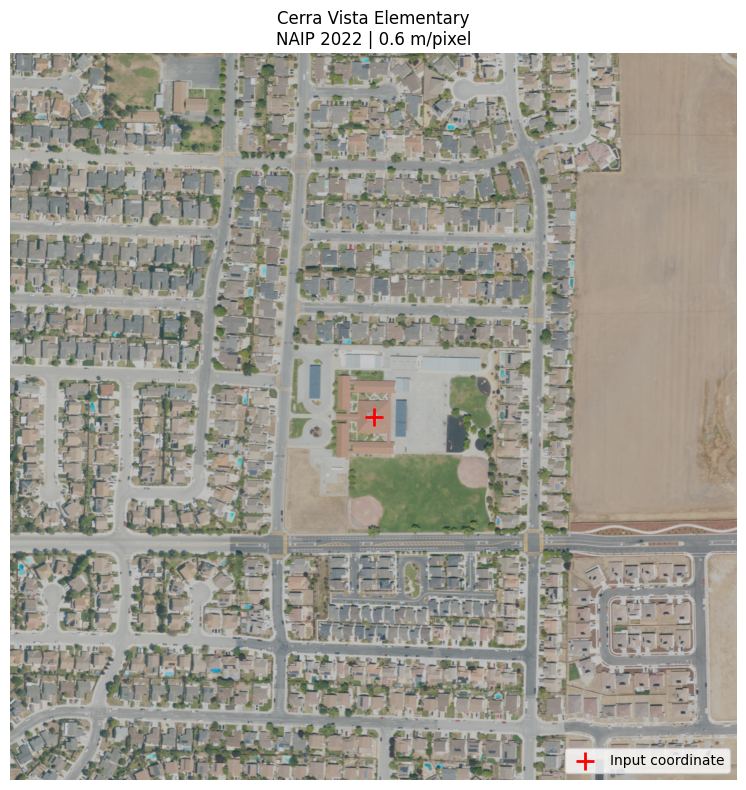

Saved GeoTIFF: outputs/naip_test_crops/61734009378_Cerra_Vista_Elementary.tif
Saved preview: outputs/naip_test_crops/61734009378_Cerra_Vista_Elementary_preview.png
Saved metadata: outputs/naip_test_crops/61734009378_Cerra_Vista_Elementary_metadata.json

School: Wedowee Middle School
Coordinate: 33.313157, -85.495877
Coordinate source: resolved_coordinate
Candidate NAIP items found: 28
Trying NAIP year 2023...
Coverage for 2023: 100.00%


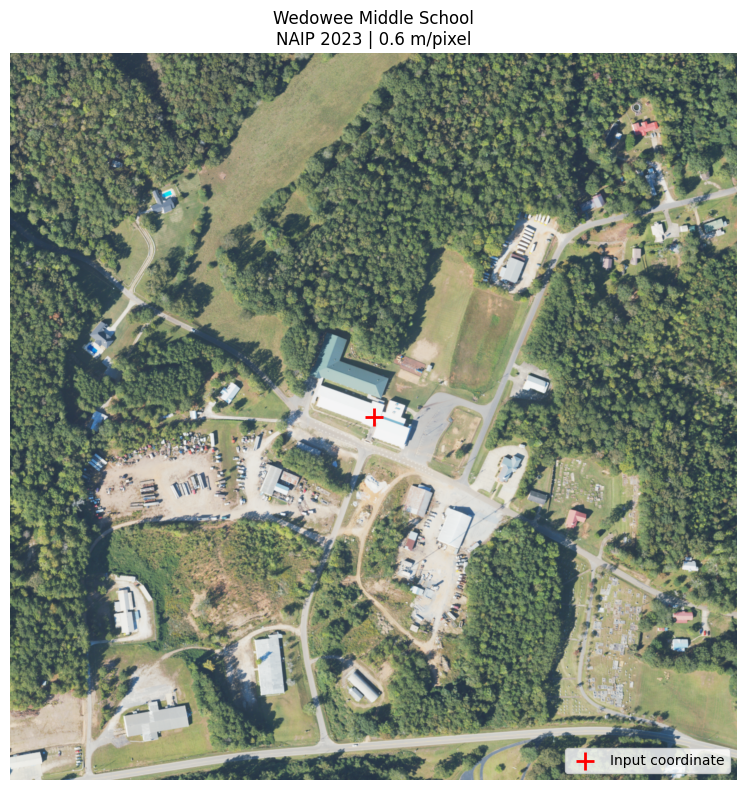

Saved GeoTIFF: outputs/naip_test_crops/10282001124_Wedowee_Middle_School.tif
Saved preview: outputs/naip_test_crops/10282001124_Wedowee_Middle_School_preview.png
Saved metadata: outputs/naip_test_crops/10282001124_Wedowee_Middle_School_metadata.json

School: Zionsville Community High School
Coordinate: 39.9611, -86.274
Coordinate source: resolved_coordinate
Candidate NAIP items found: 6
Trying NAIP year 2022...
Coverage for 2022: 100.00%


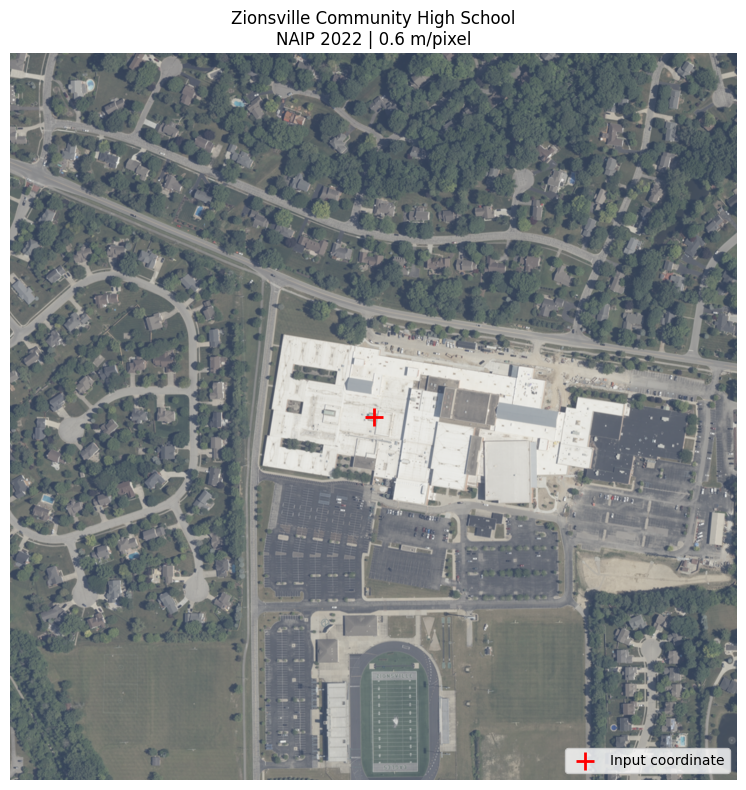

Saved GeoTIFF: outputs/naip_test_crops/180283000341_Zionsville_Community_High_School.tif
Saved preview: outputs/naip_test_crops/180283000341_Zionsville_Community_High_School_preview.png
Saved metadata: outputs/naip_test_crops/180283000341_Zionsville_Community_High_School_metadata.json


,school_id,school_name,naip_year,output_resolution_m,coverage_fraction,geotiff_file
0,61734009378,Cerra Vista Elementary,2022,0.6,1.0,outputs/naip_test_crops/61734009378_Cerra_Vist...
1,10282001124,Wedowee Middle School,2023,0.6,1.0,outputs/naip_test_crops/10282001124_Wedowee_Mi...
2,180283000341,Zionsville Community High School,2022,0.6,1.0,outputs/naip_test_crops/180283000341_Zionsvill...



Saved combined metadata to: outputs/naip_test_crops/test_naip_metadata.csv


In [9]:
TEST_SCHOOLS = [
    "Cerra Vista Elementary",
    "Wedowee Middle School",
    "Zionsville Community High School",
]

test_results = []

for school_name in TEST_SCHOOLS:

    matches = schools.loc[
        schools["school_name"].eq(school_name)
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one row for "
            f"'{school_name}', but found {len(matches)}."
        )

    print("\n" + "=" * 60)
    print(f"Downloading test crop: {school_name}")
    print("=" * 60)

    metadata = download_naip_crop(
        school=matches.iloc[0],
        crop_size_m=TEST_CROP_SIZE_M,
    )

    test_results.append(metadata)


# Combine the metadata into one table
test_metadata = pd.DataFrame(test_results)

test_metadata.to_csv(
    OUTPUT_DIR / "test_naip_metadata.csv",
    index=False,
)

display(
    test_metadata[
        [
            "school_id",
            "school_name",
            "naip_year",
            "output_resolution_m",
            "coverage_fraction",
            "geotiff_file",
        ]
    ]
)

print(
    "\nSaved combined metadata to:",
    OUTPUT_DIR / "test_naip_metadata.csv",
)


School: Cerra Vista Elementary
Coordinate: 36.829411, -121.372331
Coordinate source: resolved_coordinate
Candidate NAIP items found: 12
Trying NAIP year 2022...
Coverage for 2022: 100.00%


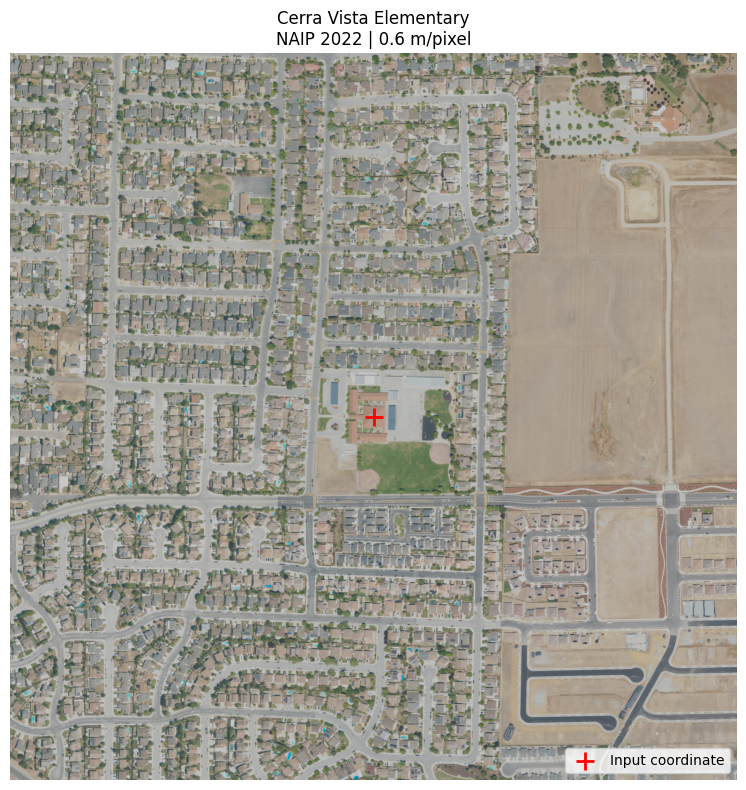

Saved GeoTIFF: outputs/naip_1200m_test_crops/61734009378_Cerra_Vista_Elementary.tif
Saved preview: outputs/naip_1200m_test_crops/61734009378_Cerra_Vista_Elementary_preview.png
Saved metadata: outputs/naip_1200m_test_crops/61734009378_Cerra_Vista_Elementary_metadata.json

School: Zionsville Community High School
Coordinate: 39.9611, -86.274
Coordinate source: resolved_coordinate
Candidate NAIP items found: 6
Trying NAIP year 2022...
Coverage for 2022: 100.00%


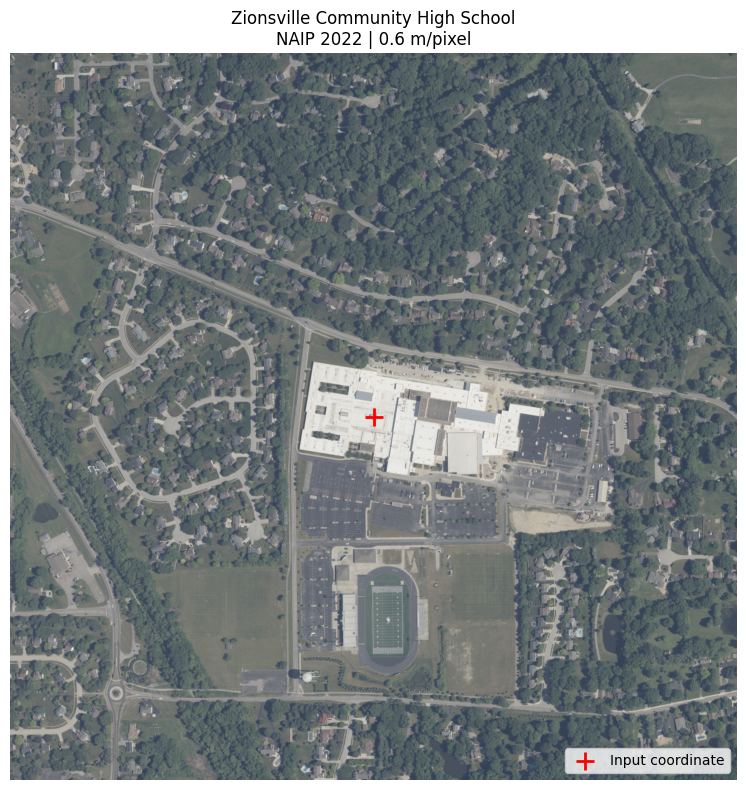

Saved GeoTIFF: outputs/naip_1200m_test_crops/180283000341_Zionsville_Community_High_School.tif
Saved preview: outputs/naip_1200m_test_crops/180283000341_Zionsville_Community_High_School_preview.png
Saved metadata: outputs/naip_1200m_test_crops/180283000341_Zionsville_Community_High_School_metadata.json


,school_id,school_name,coordinate_review_status,naip_year,crop_size_requested_m,output_width_pixels,output_height_pixels,output_resolution_m,coverage_fraction,geotiff_file
0,61734009378,Cerra Vista Elementary,confirmed,2022,1200,2000,2000,0.6,1.0,outputs/naip_1200m_test_crops/61734009378_Cerr...
1,180283000341,Zionsville Community High School,confirmed,2022,1200,2000,2000,0.6,1.0,outputs/naip_1200m_test_crops/180283000341_Zio...



Master-crop test complete.
Metadata saved to: outputs/naip_1200m_test_crops/master_crop_test_metadata.csv


In [ ]:
from pathlib import Path

import pandas as pd


# --------------------------------------------------
# Master-crop configuration
# --------------------------------------------------

MASTER_CROP_SIZE_M = 1200

# Use a new directory so the earlier 800 m tests
# are not overwritten.
OUTPUT_DIR = Path(
    "outputs/naip_1200m_test_crops"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------
# Test one primary and one large high school
# --------------------------------------------------

TEST_SCHOOLS = [
    "Cerra Vista Elementary",
    "Zionsville Community High School",
]

master_test_results = []


for school_name in TEST_SCHOOLS:

    matching_rows = schools.loc[
        schools["school_name"].eq(school_name)
    ]

    if len(matching_rows) != 1:
        raise ValueError(
            f"Expected exactly one row for "
            f"'{school_name}', but found "
            f"{len(matching_rows)}."
        )

    school = matching_rows.iloc[0]

    print("\n" + "=" * 70)
    print(
        f"Downloading 1,200 m master crop: "
        f"{school_name}"
    )
    print("=" * 70)

    metadata = download_naip_crop(
        school=school,
        crop_size_m=MASTER_CROP_SIZE_M,
    )

    master_test_results.append(metadata)


# --------------------------------------------------
# Save combined test metadata
# --------------------------------------------------

master_test_metadata = pd.DataFrame(
    master_test_results
)

MASTER_METADATA_PATH = (
    OUTPUT_DIR / "master_crop_test_metadata.csv"
)

master_test_metadata.to_csv(
    MASTER_METADATA_PATH,
    index=False,
)


# --------------------------------------------------
# Display summary
# --------------------------------------------------

display(
    master_test_metadata[
        [
            "school_id",
            "school_name",
            "coordinate_review_status",
            "naip_year",
            "crop_size_requested_m",
            "output_width_pixels",
            "output_height_pixels",
            "output_resolution_m",
            "coverage_fraction",
            "geotiff_file",
        ]
    ]
)

print("\nMaster-crop test complete.")
print(f"Metadata saved to: {MASTER_METADATA_PATH}")

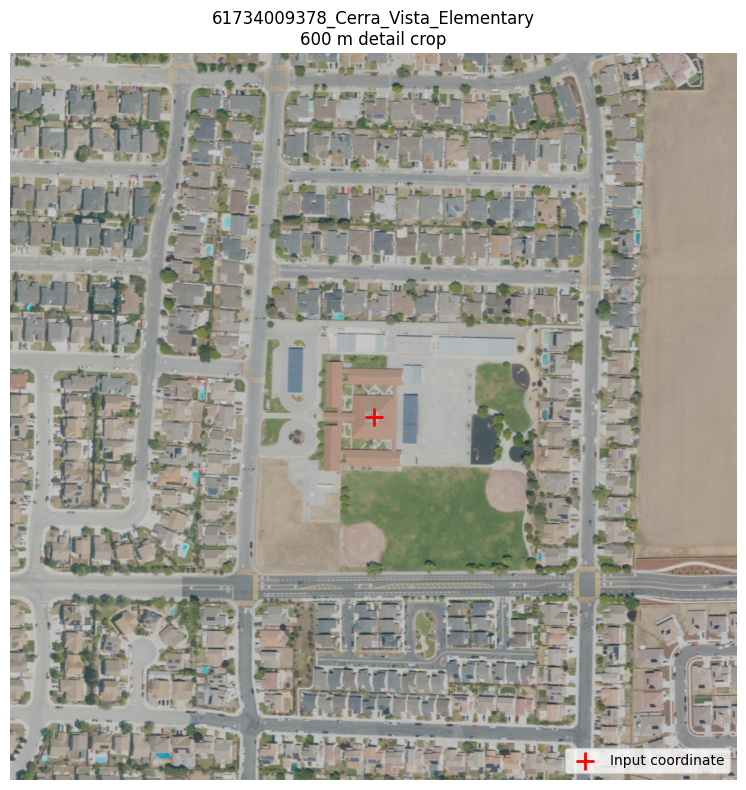

Saved detail GeoTIFF: outputs/naip_600m_detail_crops/61734009378_Cerra_Vista_Elementary_detail_600m.tif
Saved detail preview: outputs/naip_600m_detail_crops/61734009378_Cerra_Vista_Elementary_detail_600m_preview.png



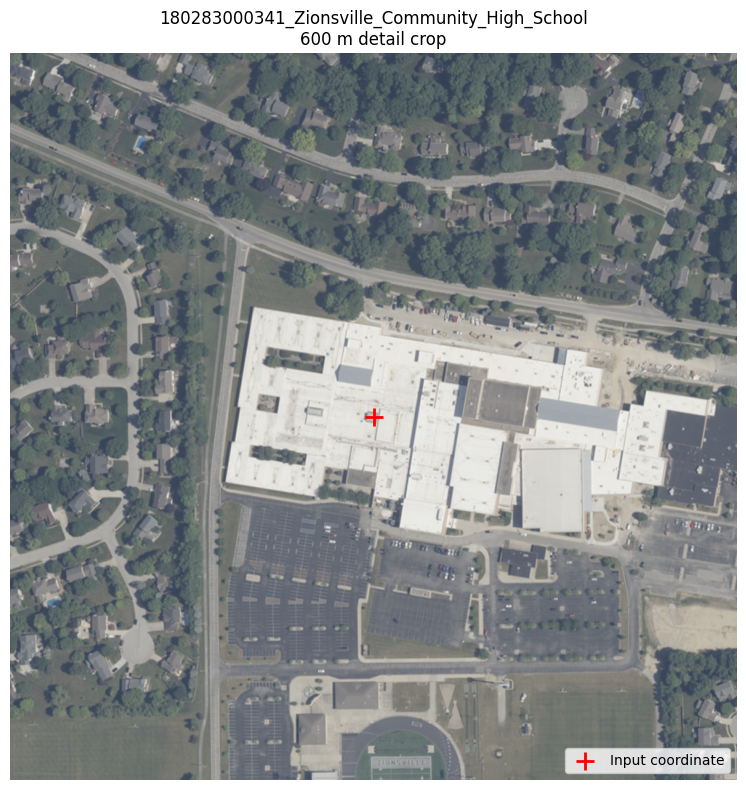

Saved detail GeoTIFF: outputs/naip_600m_detail_crops/180283000341_Zionsville_Community_High_School_detail_600m.tif
Saved detail preview: outputs/naip_600m_detail_crops/180283000341_Zionsville_Community_High_School_detail_600m_preview.png


,master_geotiff,detail_geotiff,detail_preview,detail_crop_size_m,detail_width_pixels,detail_height_pixels,resolution_x_m,resolution_y_m
0,outputs/naip_1200m_test_crops/61734009378_Cerr...,outputs/naip_600m_detail_crops/61734009378_Cer...,outputs/naip_600m_detail_crops/61734009378_Cer...,600,1000,1000,0.6,0.6
1,outputs/naip_1200m_test_crops/180283000341_Zio...,outputs/naip_600m_detail_crops/180283000341_Zi...,outputs/naip_600m_detail_crops/180283000341_Zi...,600,1000,1000,0.6,0.6



Detail-crop metadata saved to: outputs/naip_600m_detail_crops/detail_crop_test_metadata.csv


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from rasterio.windows import Window


# --------------------------------------------------
# Configuration
# --------------------------------------------------

DETAIL_CROP_SIZE_M = 600

DETAIL_OUTPUT_DIR = Path(
    "outputs/naip_600m_detail_crops"
)

DETAIL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------
# Create a detail crop from a master GeoTIFF
# --------------------------------------------------

def create_detail_crop(
    master_geotiff_path,
    detail_size_m=DETAIL_CROP_SIZE_M,
):
    master_geotiff_path = Path(
        master_geotiff_path
    )

    detail_name = (
        f"{master_geotiff_path.stem}_"
        f"detail_{detail_size_m}m.tif"
    )

    preview_name = (
        f"{master_geotiff_path.stem}_"
        f"detail_{detail_size_m}m_preview.png"
    )

    detail_path = (
        DETAIL_OUTPUT_DIR / detail_name
    )

    preview_path = (
        DETAIL_OUTPUT_DIR / preview_name
    )

    with rasterio.open(
        master_geotiff_path
    ) as source:

        resolution_x = abs(
            source.transform.a
        )

        resolution_y = abs(
            source.transform.e
        )

        detail_width = int(
            round(
                detail_size_m / resolution_x
            )
        )

        detail_height = int(
            round(
                detail_size_m / resolution_y
            )
        )

        # Ensure the requested crop is not larger
        # than the master image.
        detail_width = min(
            detail_width,
            source.width,
        )

        detail_height = min(
            detail_height,
            source.height,
        )

        column_offset = int(
            (source.width - detail_width) / 2
        )

        row_offset = int(
            (source.height - detail_height) / 2
        )

        detail_window = Window(
            col_off=column_offset,
            row_off=row_offset,
            width=detail_width,
            height=detail_height,
        )

        detail_data = source.read(
            window=detail_window
        )

        detail_transform = (
            source.window_transform(
                detail_window
            )
        )

        detail_profile = (
            source.profile.copy()
        )

        detail_profile.update(
            {
                "height": detail_height,
                "width": detail_width,
                "transform": detail_transform,
            }
        )

        original_tags = source.tags()

    # Save a georeferenced detail GeoTIFF.
    with rasterio.open(
        detail_path,
        "w",
        **detail_profile,
    ) as destination:

        destination.write(detail_data)

        destination.update_tags(
            **original_tags,
            product_role="detail_crop",
            parent_master_file=str(
                master_geotiff_path
            ),
            detail_crop_size_m=str(
                detail_size_m
            ),
        )

    # --------------------------------------------------
    # Create a human-readable PNG preview
    # --------------------------------------------------

    rgb = np.moveaxis(
        detail_data[:3],
        0,
        -1,
    )

    if rgb.dtype != np.uint8:
        valid_values = rgb[
            np.any(rgb != 0, axis=2)
        ]

        if valid_values.size:
            lower, upper = np.percentile(
                valid_values,
                [2, 98],
            )

            if upper > lower:
                rgb = np.clip(
                    (rgb - lower)
                    / (upper - lower),
                    0,
                    1,
                )

    plt.figure(figsize=(8, 8))
    plt.imshow(rgb)

    # The input coordinate remains at the center.
    plt.scatter(
        detail_width / 2,
        detail_height / 2,
        marker="+",
        s=180,
        linewidths=2,
        color="red",
        label="Input coordinate",
    )

    plt.title(
        f"{master_geotiff_path.stem}\n"
        f"{detail_size_m} m detail crop"
    )

    plt.legend(loc="lower right")
    plt.axis("off")
    plt.tight_layout()

    plt.savefig(
        preview_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    print(f"Saved detail GeoTIFF: {detail_path}")
    print(f"Saved detail preview: {preview_path}")

    return {
        "master_geotiff": str(
            master_geotiff_path
        ),
        "detail_geotiff": str(
            detail_path
        ),
        "detail_preview": str(
            preview_path
        ),
        "detail_crop_size_m": (
            detail_size_m
        ),
        "detail_width_pixels": (
            detail_width
        ),
        "detail_height_pixels": (
            detail_height
        ),
        "resolution_x_m": resolution_x,
        "resolution_y_m": resolution_y,
    }


# --------------------------------------------------
# Create detail crops for the master test images
# --------------------------------------------------

if "master_test_metadata" not in globals():
    raise RuntimeError(
        "Run the 1,200 m master-crop test cell first."
    )

detail_results = []

for master_path in master_test_metadata[
    "geotiff_file"
]:
    print("\n" + "=" * 70)

    result = create_detail_crop(
        master_geotiff_path=master_path,
        detail_size_m=DETAIL_CROP_SIZE_M,
    )

    detail_results.append(result)


# --------------------------------------------------
# Save detail-crop metadata
# --------------------------------------------------

detail_metadata = pd.DataFrame(
    detail_results
)

DETAIL_METADATA_PATH = (
    DETAIL_OUTPUT_DIR
    / "detail_crop_test_metadata.csv"
)

detail_metadata.to_csv(
    DETAIL_METADATA_PATH,
    index=False,
)

display(detail_metadata)

print(
    "\nDetail-crop metadata saved to:",
    DETAIL_METADATA_PATH,
)

In [ ]:
from pathlib import Path
from google.colab import drive
from IPython.display import display

import json
import matplotlib.pyplot as plt
import pandas as pd


# --------------------------------------------------
# Confirm required objects exist
# --------------------------------------------------

if "schools" not in globals():
    raise RuntimeError(
        "Run the CSV preparation cells first."
    )

if "download_naip_crop" not in globals():
    raise RuntimeError(
        "Run the cell that defines download_naip_crop() first."
    )

if "safe_filename" not in globals():
    raise RuntimeError(
        "Run the NAIP downloader-definition cell first."
    )


# --------------------------------------------------
# Mount Google Drive
# --------------------------------------------------

drive.mount("/content/drive")


# --------------------------------------------------
# Batch configuration
# --------------------------------------------------

MASTER_CROP_SIZE_M = 1200

PROJECT_DIRECTORY = Path(
    "/content/drive/MyDrive/"
    "school_imagery_assignment"
)

# download_naip_crop() uses this global directory.
OUTPUT_DIR = (
    PROJECT_DIRECTORY
    / "naip_master_1200m"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BATCH_METADATA_PATH = (
    OUTPUT_DIR
    / "naip_master_metadata.csv"
)


# --------------------------------------------------
# Preserve coordinate-review concerns
# --------------------------------------------------

# This is an imagery-review field. It does not change
# the original coordinate-validation result.
schools["imagery_identity_status"] = (
    "pending_naip_review"
)

schools.loc[
    schools["school_name"].eq(
        "Kofa High School"
    ),
    "imagery_identity_status",
] = "coordinate_uncertain"

schools.loc[
    schools["school_name"].eq(
        "Wedowee Middle School"
    ),
    "imagery_identity_status",
] = "needs_secondary_identity_verification"


# --------------------------------------------------
# Batch download
# --------------------------------------------------

batch_results = []

# The function will still save PNG previews, but this
# prevents 25 large figures from filling the notebook.
original_plt_show = plt.show
plt.show = lambda *args, **kwargs: None


try:
    for position, (_, school) in enumerate(
        schools.iterrows(),
        start=1,
    ):
        school_name = school["school_name"]
        school_id = str(school["school_id"])

        school_slug = safe_filename(
            school_name
        )

        base_name = (
            f"{school_id}_{school_slug}"
        )

        geotiff_path = (
            OUTPUT_DIR
            / f"{base_name}.tif"
        )

        preview_path = (
            OUTPUT_DIR
            / f"{base_name}_preview.png"
        )

        metadata_path = (
            OUTPUT_DIR
            / f"{base_name}_metadata.json"
        )

        print("\n" + "=" * 70)
        print(
            f"[{position:02d}/{len(schools)}] "
            f"{school_name}"
        )
        print("=" * 70)

        try:
            # Resume support: do not download a completed
            # school again when the cell is rerun.
            if (
                geotiff_path.exists()
                and preview_path.exists()
                and metadata_path.exists()
            ):
                print(
                    "Existing completed files found. "
                    "Skipping download."
                )

                with metadata_path.open(
                    "r",
                    encoding="utf-8",
                ) as file_handle:
                    metadata = json.load(
                        file_handle
                    )

            else:
                metadata = download_naip_crop(
                    school=school,
                    crop_size_m=(
                        MASTER_CROP_SIZE_M
                    ),
                )

            # Add the imagery identity-review status.
            metadata[
                "imagery_identity_status"
            ] = school[
                "imagery_identity_status"
            ]

            metadata[
                "batch_download_status"
            ] = "success"

            # Update the per-school metadata file.
            with metadata_path.open(
                "w",
                encoding="utf-8",
            ) as file_handle:
                json.dump(
                    metadata,
                    file_handle,
                    indent=2,
                )

            batch_results.append(
                metadata
            )

        except Exception as error:
            print(
                f"Download failed: "
                f"{type(error).__name__}: {error}"
            )

            batch_results.append(
                {
                    "school_id": school_id,
                    "school_name": school_name,
                    "school_level": (
                        school["level"]
                    ),
                    "coordinate_review_status": (
                        school[
                            "basemap_review_status"
                        ]
                    ),
                    "imagery_identity_status": (
                        school[
                            "imagery_identity_status"
                        ]
                    ),
                    "batch_download_status": (
                        "failed"
                    ),
                    "error_type": (
                        type(error).__name__
                    ),
                    "error_message": str(error),
                }
            )

        # Save a checkpoint after every school.
        master_metadata = pd.DataFrame(
            batch_results
        )

        master_metadata.to_csv(
            BATCH_METADATA_PATH,
            index=False,
        )

finally:
    # Restore normal plotting behaviour.
    plt.show = original_plt_show


# --------------------------------------------------
# Final batch summary
# --------------------------------------------------

master_metadata = pd.DataFrame(
    batch_results
)

successful_downloads = (
    master_metadata[
        "batch_download_status"
    ]
    .eq("success")
    .sum()
)

failed_downloads = (
    master_metadata[
        "batch_download_status"
    ]
    .eq("failed")
    .sum()
)


print("\n" + "=" * 70)
print("NAIP MASTER DOWNLOAD SUMMARY")
print("=" * 70)

print(f"Total schools:        {len(schools)}")
print(f"Successful downloads: {successful_downloads}")
print(f"Failed downloads:     {failed_downloads}")
print(f"Master crop size:     {MASTER_CROP_SIZE_M} m")
print(f"Output directory:     {OUTPUT_DIR}")
print(f"Metadata checkpoint:  {BATCH_METADATA_PATH}")


# --------------------------------------------------
# Display batch results
# --------------------------------------------------

summary_columns = [
    "school_id",
    "school_name",
    "school_level",
    "naip_year",
    "output_resolution_m",
    "coverage_fraction",
    "coordinate_review_status",
    "coordinate_source",
    "imagery_identity_status",
    "batch_download_status",
]

available_summary_columns = [
    column
    for column in summary_columns
    if column in master_metadata.columns
]

display(
    master_metadata[
        available_summary_columns
    ]
)


# --------------------------------------------------
# Display download failures
# --------------------------------------------------

failed_rows = master_metadata.loc[
    master_metadata[
        "batch_download_status"
    ].eq("failed")
]

if failed_rows.empty:
    print(
        "\nAll 25 NAIP master crops downloaded "
        "successfully."
    )
else:
    print(
        "\nThe following schools require "
        "download troubleshooting:"
    )

    failure_columns = [
        "school_id",
        "school_name",
        "error_type",
        "error_message",
    ]

    available_failure_columns = [
        column
        for column in failure_columns
        if column in failed_rows.columns
    ]

    display(
        failed_rows[
            available_failure_columns
        ]
    )


# --------------------------------------------------
# Display schools requiring identity follow-up
# --------------------------------------------------

identity_followup = master_metadata.loc[
    master_metadata[
        "imagery_identity_status"
    ].ne("pending_naip_review")
]

if identity_followup.empty:
    print(
        "\nNo schools are currently flagged for "
        "identity follow-up."
    )
else:
    print(
        "\nSchools requiring identity follow-up:"
    )

    followup_columns = [
        "school_id",
        "school_name",
        "coordinate_review_status",
        "coordinate_source",
        "imagery_identity_status",
        "geotiff_file",
        "preview_file",
    ]

    available_followup_columns = [
        column
        for column in followup_columns
        if column in identity_followup.columns
    ]

    display(
        identity_followup[
            available_followup_columns
        ]
    )


# --------------------------------------------------
# Confirm checkpoint was saved
# --------------------------------------------------

if BATCH_METADATA_PATH.exists():
    print(
        "\nCheckpoint CSV saved successfully:"
    )
    print(BATCH_METADATA_PATH)
else:
    raise RuntimeError(
        "The batch metadata checkpoint was not saved."
    )

Mounted at /content/drive

[01/25] Wedowee Middle School
School: Wedowee Middle School
Coordinate: 33.313157, -85.495877
Coordinate source: resolved_coordinate
Candidate NAIP items found: 28
Trying NAIP year 2023...
Coverage for 2023: 100.00%
Saved GeoTIFF: /content/drive/MyDrive/school_imagery_assignment/naip_master_1200m/10282001124_Wedowee_Middle_School.tif
Saved preview: /content/drive/MyDrive/school_imagery_assignment/naip_master_1200m/10282001124_Wedowee_Middle_School_preview.png
Saved metadata: /content/drive/MyDrive/school_imagery_assignment/naip_master_1200m/10282001124_Wedowee_Middle_School_metadata.json

[02/25] Kofa High School
School: Kofa High School
Coordinate: 32.6743, -114.636
Coordinate source: original_coordinate_flagged_for_review
Candidate NAIP items found: 7
Trying NAIP year 2023...
Coverage for 2023: 100.00%
Saved GeoTIFF: /content/drive/MyDrive/school_imagery_assignment/naip_master_1200m/40963000996_Kofa_High_School.tif
Saved preview: /content/drive/MyDrive/scho

Saved GeoTIFF: /content/drive/MyDrive/school_imagery_assignment/naip_master_1200m/130333001308_Lincoln_County_Elementary_School.tif
Saved preview: /content/drive/MyDrive/school_imagery_assignment/naip_master_1200m/130333001308_Lincoln_County_Elementary_School_preview.png
Saved metadata: /content/drive/MyDrive/school_imagery_assignment/naip_master_1200m/130333001308_Lincoln_County_Elementary_School_metadata.json

[07/25] CLAUDE A WILCOX ELEMENTARY SCHOOL
School: CLAUDE A WILCOX ELEMENTARY SCHOOL
Coordinate: 42.898474, -112.47438
Coordinate source: resolved_coordinate
Candidate NAIP items found: 7
Trying NAIP year 2023...
Coverage for 2023: 100.00%
Saved GeoTIFF: /content/drive/MyDrive/school_imagery_assignment/naip_master_1200m/160264000465_CLAUDE_A_WILCOX_ELEMENTARY_SCHOOL.tif
Saved preview: /content/drive/MyDrive/school_imagery_assignment/naip_master_1200m/160264000465_CLAUDE_A_WILCOX_ELEMENTARY_SCHOOL_preview.png
Saved metadata: /content/drive/MyDrive/school_imagery_assignment/naip_m

,school_id,school_name,school_level,naip_year,output_resolution_m,coverage_fraction,coordinate_review_status,coordinate_source,imagery_identity_status,batch_download_status
0,10282001124,Wedowee Middle School,Middle,2023,0.6,1.0,confirmed,resolved_coordinate,needs_secondary_identity_verification,success
1,40963000996,Kofa High School,High,2023,0.3,1.0,uncertain,original_coordinate_flagged_for_review,coordinate_uncertain,success
2,60483000471,Beverly Hills High,High,2022,0.6,1.0,confirmed_with_offset,resolved_coordinate,pending_naip_review,success
3,61734009378,Cerra Vista Elementary,Primary,2022,0.6,1.0,confirmed,resolved_coordinate,pending_naip_review,success
4,60001909278,Wells Middle,Middle,2022,0.6,1.0,confirmed,resolved_coordinate,pending_naip_review,success
5,130333001308,Lincoln County Elementary School,Primary,2023,0.6,1.0,confirmed,resolved_coordinate,pending_naip_review,success
6,160264000465,CLAUDE A WILCOX ELEMENTARY SCHOOL,Primary,2023,0.6,1.0,confirmed,resolved_coordinate,pending_naip_review,success
7,160000100084,PRIEST RIVER LAMANNA HIGH,High,2023,0.6,1.0,confirmed,resolved_coordinate,pending_naip_review,success
8,180283000341,Zionsville Community High School,High,2022,0.6,1.0,confirmed,resolved_coordinate,pending_naip_review,success
9,240039000683,Bel Air High,High,2023,0.3,1.0,confirmed,resolved_coordinate,pending_naip_review,success



All 25 NAIP master crops downloaded successfully.

Schools requiring identity follow-up:


,school_id,school_name,coordinate_review_status,coordinate_source,imagery_identity_status,geotiff_file,preview_file
0,10282001124,Wedowee Middle School,confirmed,resolved_coordinate,needs_secondary_identity_verification,/content/drive/MyDrive/school_imagery_assignme...,/content/drive/MyDrive/school_imagery_assignme...
1,40963000996,Kofa High School,uncertain,original_coordinate_flagged_for_review,coordinate_uncertain,/content/drive/MyDrive/school_imagery_assignme...,/content/drive/MyDrive/school_imagery_assignme...



Checkpoint CSV saved successfully:
/content/drive/MyDrive/school_imagery_assignment/naip_master_1200m/naip_master_metadata.csv


In [ ]:
from pathlib import Path
from google.colab import drive

import json
import matplotlib.pyplot as plt
import pandas as pd


# --------------------------------------------------
# Confirm required notebook objects exist
# --------------------------------------------------

if "schools" not in globals():
    raise RuntimeError(
        "Run the CSV loading and validation cells first."
    )

if "download_naip_crop" not in globals():
    raise RuntimeError(
        "Run the NAIP downloader-definition cell first."
    )

if "safe_filename" not in globals():
    raise RuntimeError(
        "The safe_filename function is missing. "
        "Run the downloader-definition cell first."
    )


# --------------------------------------------------
# Mount Google Drive
# --------------------------------------------------

drive.mount("/content/drive")


# --------------------------------------------------
# Persistent output locations
# --------------------------------------------------

PROJECT_DIRECTORY = Path(
    "/content/drive/MyDrive/"
    "school_imagery_assignment"
)

OUTPUT_DIR = (
    PROJECT_DIRECTORY
    / "naip_master_1200m"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BATCH_METADATA_PATH = (
    OUTPUT_DIR
    / "naip_master_metadata.csv"
)

MASTER_CROP_SIZE_M = 1200


# --------------------------------------------------
# Preserve coordinate/identity uncertainty
# --------------------------------------------------

schools["imagery_identity_status"] = (
    "pending_naip_review"
)

schools.loc[
    schools["school_name"].eq(
        "Kofa High School"
    ),
    "imagery_identity_status",
] = "coordinate_uncertain"

schools.loc[
    schools["school_name"].eq(
        "Wedowee Middle School"
    ),
    "imagery_identity_status",
] = "needs_secondary_verification"


# --------------------------------------------------
# Batch-download all master crops
# --------------------------------------------------

batch_results = []

# Prevent 25 large previews from appearing during
# the batch. The PNG previews are still saved.
original_plt_show = plt.show
plt.show = lambda *args, **kwargs: None


try:
    for position, (_, school) in enumerate(
        schools.iterrows(),
        start=1,
    ):
        school_id = str(
            school["school_id"]
        )

        school_name = str(
            school["school_name"]
        )

        school_slug = safe_filename(
            school_name
        )

        base_name = (
            f"{school_id}_{school_slug}"
        )

        geotiff_path = (
            OUTPUT_DIR
            / f"{base_name}.tif"
        )

        preview_path = (
            OUTPUT_DIR
            / f"{base_name}_preview.png"
        )

        metadata_path = (
            OUTPUT_DIR
            / f"{base_name}_metadata.json"
        )

        print("\n" + "=" * 70)
        print(
            f"[{position:02d}/{len(schools)}] "
            f"{school_name}"
        )
        print("=" * 70)

        try:
            # ------------------------------------------
            # Resume an existing completed download
            # ------------------------------------------

            if (
                geotiff_path.exists()
                and preview_path.exists()
                and metadata_path.exists()
            ):
                print(
                    "Existing completed files found; "
                    "skipping download."
                )

                with metadata_path.open(
                    "r",
                    encoding="utf-8",
                ) as file_handle:
                    metadata = json.load(
                        file_handle
                    )

            # ------------------------------------------
            # Download a new master crop
            # ------------------------------------------

            else:
                metadata = download_naip_crop(
                    school=school,
                    crop_size_m=(
                        MASTER_CROP_SIZE_M
                    ),
                )

            # Add review information from the CSV.
            metadata[
                "imagery_identity_status"
            ] = school[
                "imagery_identity_status"
            ]

            metadata[
                "basemap_review_status"
            ] = school[
                "basemap_review_status"
            ]

            metadata[
                "batch_download_status"
            ] = "success"

            metadata[
                "requires_manual_followup"
            ] = (
                school[
                    "imagery_identity_status"
                ]
                != "pending_naip_review"
            )

            # Update the individual metadata JSON.
            with metadata_path.open(
                "w",
                encoding="utf-8",
            ) as file_handle:
                json.dump(
                    metadata,
                    file_handle,
                    indent=2,
                )

            batch_results.append(
                metadata
            )

            print("Batch status: success")

        except Exception as error:
            print(
                "Batch status: failed —",
                type(error).__name__,
                str(error),
            )

            batch_results.append(
                {
                    "school_id": school_id,
                    "school_name": school_name,
                    "school_level": school["level"],
                    "coordinate_review_status": (
                        school[
                            "basemap_review_status"
                        ]
                    ),
                    "imagery_identity_status": (
                        school[
                            "imagery_identity_status"
                        ]
                    ),
                    "batch_download_status": (
                        "failed"
                    ),
                    "requires_manual_followup": True,
                    "error_type": (
                        type(error).__name__
                    ),
                    "error_message": str(error),
                }
            )

        # Save a checkpoint after every school.
        master_metadata = pd.DataFrame(
            batch_results
        )

        master_metadata.to_csv(
            BATCH_METADATA_PATH,
            index=False,
        )

finally:
    # Restore normal notebook plotting.
    plt.show = original_plt_show


# --------------------------------------------------
# Final batch summary
# --------------------------------------------------

master_metadata = pd.DataFrame(
    batch_results
)

successful_downloads = (
    master_metadata[
        "batch_download_status"
    ]
    .eq("success")
    .sum()
)

failed_downloads = (
    master_metadata[
        "batch_download_status"
    ]
    .eq("failed")
    .sum()
)

print("\n" + "=" * 70)
print("NAIP MASTER DOWNLOAD SUMMARY")
print("=" * 70)

print(f"Total schools:          {len(schools)}")
print(f"Successful downloads:   {successful_downloads}")
print(f"Failed downloads:       {failed_downloads}")
print(f"Master crop size:       {MASTER_CROP_SIZE_M} m")
print(f"Metadata checkpoint:    {BATCH_METADATA_PATH}")


summary_columns = [
    "school_id",
    "school_name",
    "school_level",
    "naip_year",
    "output_resolution_m",
    "coverage_fraction",
    "coordinate_review_status",
    "imagery_identity_status",
    "batch_download_status",
]

available_summary_columns = [
    column
    for column in summary_columns
    if column in master_metadata.columns
]

display(
    master_metadata[
        available_summary_columns
    ]
)


# Display failures separately
failed_rows = master_metadata.loc[
    master_metadata[
        "batch_download_status"
    ].eq("failed")
]

if not failed_rows.empty:
    print("\nSchools requiring download troubleshooting:")

    display(
        failed_rows[
            [
                "school_id",
                "school_name",
                "error_type",
                "error_message",
            ]
        ]
    )
else:
    print(
        "\nAll 25 master crops downloaded successfully."
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[01/25] Wedowee Middle School
Existing completed files found; skipping download.
Batch status: success

[02/25] Kofa High School
Existing completed files found; skipping download.
Batch status: success

[03/25] Beverly Hills High
Existing completed files found; skipping download.
Batch status: success

[04/25] Cerra Vista Elementary
Existing completed files found; skipping download.
Batch status: success

[05/25] Wells Middle
Existing completed files found; skipping download.
Batch status: success

[06/25] Lincoln County Elementary School
Existing completed files found; skipping download.
Batch status: success

[07/25] CLAUDE A WILCOX ELEMENTARY SCHOOL
Existing completed files found; skipping download.
Batch status: success

[08/25] PRIEST RIVER LAMANNA HIGH
Existing completed files found; skipping download.
Batch status: success

[09/25] Zionsville Communit

,school_id,school_name,school_level,naip_year,output_resolution_m,coverage_fraction,coordinate_review_status,imagery_identity_status,batch_download_status
0,10282001124,Wedowee Middle School,Middle,2023,0.6,1.0,confirmed,needs_secondary_verification,success
1,40963000996,Kofa High School,High,2023,0.3,1.0,uncertain,coordinate_uncertain,success
2,60483000471,Beverly Hills High,High,2022,0.6,1.0,confirmed_with_offset,pending_naip_review,success
3,61734009378,Cerra Vista Elementary,Primary,2022,0.6,1.0,confirmed,pending_naip_review,success
4,60001909278,Wells Middle,Middle,2022,0.6,1.0,confirmed,pending_naip_review,success
5,130333001308,Lincoln County Elementary School,Primary,2023,0.6,1.0,confirmed,pending_naip_review,success
6,160264000465,CLAUDE A WILCOX ELEMENTARY SCHOOL,Primary,2023,0.6,1.0,confirmed,pending_naip_review,success
7,160000100084,PRIEST RIVER LAMANNA HIGH,High,2023,0.6,1.0,confirmed,pending_naip_review,success
8,180283000341,Zionsville Community High School,High,2022,0.6,1.0,confirmed,pending_naip_review,success
9,240039000683,Bel Air High,High,2023,0.3,1.0,confirmed,pending_naip_review,success



All 25 master crops downloaded successfully.


In [ ]:
from pathlib import Path

import pandas as pd


# --------------------------------------------------
# Load the saved batch metadata
# --------------------------------------------------

if "BATCH_METADATA_PATH" not in globals():
    BATCH_METADATA_PATH = Path(
        "/content/drive/MyDrive/"
        "school_imagery_assignment/"
        "naip_master_1200m/"
        "naip_master_metadata.csv"
    )

if not BATCH_METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Metadata CSV not found: {BATCH_METADATA_PATH}"
    )

master_metadata = pd.read_csv(
    BATCH_METADATA_PATH,
    dtype={"school_id": "string"},
)


# --------------------------------------------------
# Check row counts and duplicates
# --------------------------------------------------

total_rows = len(master_metadata)

unique_school_ids = (
    master_metadata["school_id"]
    .nunique()
)

duplicate_school_ids = master_metadata.loc[
    master_metadata[
        "school_id"
    ].duplicated(keep=False)
]


# --------------------------------------------------
# Check download status
# --------------------------------------------------

successful_rows = master_metadata.loc[
    master_metadata[
        "batch_download_status"
    ].eq("success")
].copy()

failed_rows = master_metadata.loc[
    master_metadata[
        "batch_download_status"
    ].ne("success")
].copy()


# --------------------------------------------------
# Check whether output files actually exist
# --------------------------------------------------

def file_exists(file_path):
    if pd.isna(file_path):
        return False

    return Path(file_path).exists()


master_metadata["geotiff_exists"] = (
    master_metadata["geotiff_file"]
    .apply(file_exists)
)

master_metadata["preview_exists"] = (
    master_metadata["preview_file"]
    .apply(file_exists)
)


# --------------------------------------------------
# Check imagery coverage
# --------------------------------------------------

master_metadata["coverage_fraction"] = (
    pd.to_numeric(
        master_metadata[
            "coverage_fraction"
        ],
        errors="coerce",
    )
)

master_metadata["coverage_passed"] = (
    master_metadata[
        "coverage_fraction"
    ].ge(0.98)
)


# --------------------------------------------------
# Determine technical readiness
# --------------------------------------------------

master_metadata["technically_ready"] = (
    master_metadata[
        "batch_download_status"
    ].eq("success")
    & master_metadata["geotiff_exists"]
    & master_metadata["preview_exists"]
    & master_metadata["coverage_passed"]
)


technical_problems = master_metadata.loc[
    ~master_metadata["technically_ready"]
].copy()


# --------------------------------------------------
# Identify manual-review cases
# --------------------------------------------------

identity_followup = master_metadata.loc[
    master_metadata[
        "imagery_identity_status"
    ].ne("pending_naip_review")
].copy()


# --------------------------------------------------
# Print readiness summary
# --------------------------------------------------

print("=" * 70)
print("ATTRIBUTE-EXTRACTION READINESS CHECK")
print("=" * 70)

print(f"Expected schools:            25")
print(f"Metadata rows:               {total_rows}")
print(f"Unique school IDs:           {unique_school_ids}")
print(f"Successful downloads:        {len(successful_rows)}")
print(f"Failed/incomplete downloads: {len(failed_rows)}")
print(
    "Technically ready images:  ",
    int(
        master_metadata[
            "technically_ready"
        ].sum()
    ),
)
print(
    "Identity follow-up cases:  ",
    len(identity_followup),
)


# --------------------------------------------------
# Display problems
# --------------------------------------------------

if not duplicate_school_ids.empty:
    print("\nDuplicate school IDs found:")

    display(
        duplicate_school_ids[
            [
                "school_id",
                "school_name",
            ]
        ]
    )


if not technical_problems.empty:
    print("\nImages with technical problems:")

    problem_columns = [
        "school_id",
        "school_name",
        "batch_download_status",
        "geotiff_exists",
        "preview_exists",
        "coverage_fraction",
        "error_type",
        "error_message",
    ]

    available_problem_columns = [
        column
        for column in problem_columns
        if column in technical_problems.columns
    ]

    display(
        technical_problems[
            available_problem_columns
        ]
    )


if not identity_followup.empty:
    print("\nImages requiring identity follow-up:")

    followup_columns = [
        "school_id",
        "school_name",
        "coordinate_review_status",
        "coordinate_source",
        "imagery_identity_status",
        "preview_file",
    ]

    available_followup_columns = [
        column
        for column in followup_columns
        if column in identity_followup.columns
    ]

    display(
        identity_followup[
            available_followup_columns
        ]
    )


# --------------------------------------------------
# Final decision
# --------------------------------------------------

all_technically_ready = (
    total_rows == 25
    and unique_school_ids == 25
    and master_metadata[
        "technically_ready"
    ].all()
)

if all_technically_ready:
    print(
        "\nAll 25 images passed the technical "
        "readiness checks."
    )
    print(
        "Attribute extraction can begin after "
        "reviewing the flagged identity cases."
    )
else:
    print(
        "\nDo not start attribute extraction yet. "
        "Resolve the technical problems shown above."
    )

ATTRIBUTE-EXTRACTION READINESS CHECK
Expected schools:            25
Metadata rows:               25
Unique school IDs:           25
Successful downloads:        25
Failed/incomplete downloads: 0
Technically ready images:   25
Identity follow-up cases:   2

Images requiring identity follow-up:


,school_id,school_name,coordinate_review_status,coordinate_source,imagery_identity_status,preview_file
0,10282001124,Wedowee Middle School,confirmed,resolved_coordinate,needs_secondary_verification,/content/drive/MyDrive/school_imagery_assignme...
1,40963000996,Kofa High School,uncertain,original_coordinate_flagged_for_review,coordinate_uncertain,/content/drive/MyDrive/school_imagery_assignme...



All 25 images passed the technical readiness checks.
Attribute extraction can begin after reviewing the flagged identity cases.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd


# --------------------------------------------------
# File locations
# --------------------------------------------------

PROJECT_DIRECTORY = Path(
    "/content/drive/MyDrive/"
    "school_imagery_assignment"
)

BATCH_METADATA_PATH = (
    PROJECT_DIRECTORY
    / "naip_master_1200m"
    / "naip_master_metadata.csv"
)

MEASUREMENTS_PATH = (
    PROJECT_DIRECTORY
    / "measurements_working.csv"
)


# --------------------------------------------------
# Load source data
# --------------------------------------------------

if not BATCH_METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Batch metadata not found: "
        f"{BATCH_METADATA_PATH}"
    )

master_metadata = pd.read_csv(
    BATCH_METADATA_PATH,
    dtype={"school_id": "string"},
)

schools["school_id"] = (
    schools["school_id"]
    .astype("string")
)


# --------------------------------------------------
# Verify that all 25 images are available
# --------------------------------------------------

if len(master_metadata) != 25:
    raise ValueError(
        f"Expected 25 metadata rows, "
        f"but found {len(master_metadata)}."
    )

if master_metadata[
    "school_id"
].duplicated().any():
    raise ValueError(
        "Duplicate school IDs found in master metadata."
    )

failed_downloads = master_metadata.loc[
    master_metadata[
        "batch_download_status"
    ].ne("success")
]

if not failed_downloads.empty:
    print("Failed or incomplete imagery rows:")

    display(
        failed_downloads[
            [
                "school_id",
                "school_name",
                "batch_download_status",
            ]
        ]
    )

    raise RuntimeError(
        "Resolve failed imagery downloads before "
        "creating the measurement table."
    )


# --------------------------------------------------
# Select reproducibility metadata
# --------------------------------------------------

metadata_columns = [
    "school_id",
    "naip_year",
    "naip_acquisition_datetimes",
    "output_resolution_m",
    "stac_item_ids",
    "geotiff_file",
    "preview_file",
    "coordinate_review_status",
    "coordinate_source",
    "imagery_identity_status",
]

missing_metadata_columns = [
    column
    for column in metadata_columns
    if column not in master_metadata.columns
]

if missing_metadata_columns:
    raise ValueError(
        "Missing imagery metadata columns: "
        f"{missing_metadata_columns}"
    )

imagery_metadata = master_metadata[
    metadata_columns
].copy()


# --------------------------------------------------
# Create one measurement row per school
# --------------------------------------------------

measurements = schools[
    [
        "school_id",
        "school_name",
        "district",
        "city",
        "state",
        "level",
        "enrollment_2024",
    ]
].copy()

measurements = measurements.merge(
    imagery_metadata,
    on="school_id",
    how="left",
    validate="one_to_one",
)


# --------------------------------------------------
# Required measurement fields
# --------------------------------------------------

# A. Rooftop solar
measurements["rooftop_solar_present"] = pd.Series(
    pd.NA,
    index=measurements.index,
    dtype="string",
)

measurements[
    "rooftop_solar_present_confidence"
] = np.nan

measurements["rooftop_solar_area_m2"] = np.nan

measurements[
    "rooftop_solar_area_m2_confidence"
] = np.nan


# B. Portable/modular classrooms
measurements[
    "portable_classroom_count"
] = pd.Series(
    pd.NA,
    index=measurements.index,
    dtype="Int64",
)

measurements[
    "portable_classroom_count_confidence"
] = np.nan


# C. Perimeter fencing
measurements[
    "perimeter_fencing"
] = pd.Series(
    pd.NA,
    index=measurements.index,
    dtype="string",
)

measurements[
    "perimeter_fencing_confidence"
] = np.nan

measurements[
    "dominant_fence_type"
] = pd.Series(
    pd.NA,
    index=measurements.index,
    dtype="string",
)

measurements[
    "dominant_fence_type_confidence"
] = np.nan


# D. Athletic facilities
measurements["running_track"] = pd.Series(
    pd.NA,
    index=measurements.index,
    dtype="string",
)

measurements[
    "running_track_confidence"
] = np.nan

measurements[
    "full_size_sports_fields_count"
] = pd.Series(
    pd.NA,
    index=measurements.index,
    dtype="Int64",
)

measurements[
    "full_size_sports_fields_count_confidence"
] = np.nan

measurements[
    "hard_courts_count"
] = pd.Series(
    pd.NA,
    index=measurements.index,
    dtype="Int64",
)

measurements[
    "hard_courts_count_confidence"
] = np.nan

measurements["pool_present"] = pd.Series(
    pd.NA,
    index=measurements.index,
    dtype="string",
)

measurements[
    "pool_present_confidence"
] = np.nan


# --------------------------------------------------
# Evidence and review fields
# --------------------------------------------------

measurements["imagery_source"] = (
    "USDA NAIP via Microsoft Planetary Computer"
)

measurements[
    "imagery_date_or_vintage"
] = (
    pd.to_numeric(
        measurements["naip_year"],
        errors="coerce",
    )
    .astype("Int64")
    .astype("string")
)

measurements["solar_notes"] = ""
measurements["portable_classroom_notes"] = ""
measurements["fencing_notes"] = ""
measurements["athletic_facilities_notes"] = ""

measurements["measurement_status"] = (
    "not_started"
)

measurements["review_priority"] = np.where(
    measurements[
        "imagery_identity_status"
    ].eq("pending_naip_review"),
    "standard",
    "high",
)


# --------------------------------------------------
# Arrange final columns
# --------------------------------------------------

final_columns = [
    # Identification
    "school_id",
    "school_name",
    "district",
    "city",
    "state",
    "level",
    "enrollment_2024",

    # Rooftop solar
    "rooftop_solar_present",
    "rooftop_solar_present_confidence",
    "rooftop_solar_area_m2",
    "rooftop_solar_area_m2_confidence",

    # Portable classrooms
    "portable_classroom_count",
    "portable_classroom_count_confidence",

    # Fencing
    "perimeter_fencing",
    "perimeter_fencing_confidence",
    "dominant_fence_type",
    "dominant_fence_type_confidence",

    # Athletic facilities
    "running_track",
    "running_track_confidence",
    "full_size_sports_fields_count",
    "full_size_sports_fields_count_confidence",
    "hard_courts_count",
    "hard_courts_count_confidence",
    "pool_present",
    "pool_present_confidence",

    # Imagery provenance
    "imagery_source",
    "imagery_date_or_vintage",
    "naip_acquisition_datetimes",
    "output_resolution_m",
    "stac_item_ids",
    "geotiff_file",
    "preview_file",

    # Coordinate and QA information
    "coordinate_review_status",
    "coordinate_source",
    "imagery_identity_status",
    "review_priority",
    "measurement_status",

    # Notes
    "solar_notes",
    "portable_classroom_notes",
    "fencing_notes",
    "athletic_facilities_notes",
]

measurements = measurements[
    final_columns
]


# --------------------------------------------------
# Save the working measurement table
# --------------------------------------------------

measurements.to_csv(
    MEASUREMENTS_PATH,
    index=False,
)

print("Measurement template created")
print("----------------------------")
print(f"Rows: {len(measurements)}")
print(f"Columns: {len(measurements.columns)}")
print(f"Saved to: {MEASUREMENTS_PATH}")

display(measurements.head())

Measurement template created
----------------------------
Rows: 25
Columns: 41
Saved to: /content/drive/MyDrive/school_imagery_assignment/measurements_working.csv


,school_id,school_name,district,city,state,level,enrollment_2024,rooftop_solar_present,rooftop_solar_present_confidence,rooftop_solar_area_m2,...,preview_file,coordinate_review_status,coordinate_source,imagery_identity_status,review_priority,measurement_status,solar_notes,portable_classroom_notes,fencing_notes,athletic_facilities_notes
0,10282001124,Wedowee Middle School,Randolph County,Wedowee,AL,Middle,199,<NA>,NaN,NaN,...,/content/drive/MyDrive/school_imagery_assignme...,confirmed,resolved_coordinate,needs_secondary_verification,high,not_started,,,,
1,40963000996,Kofa High School,Yuma Union High School District,Yuma,AZ,High,1976,<NA>,NaN,NaN,...,/content/drive/MyDrive/school_imagery_assignme...,uncertain,original_coordinate_flagged_for_review,coordinate_uncertain,high,not_started,,,,
2,60483000471,Beverly Hills High,Beverly Hills Unified,Beverly Hills,CA,High,1173,<NA>,NaN,NaN,...,/content/drive/MyDrive/school_imagery_assignme...,confirmed_with_offset,resolved_coordinate,pending_naip_review,standard,not_started,,,,
3,61734009378,Cerra Vista Elementary,Hollister,Hollister,CA,Primary,602,<NA>,NaN,NaN,...,/content/drive/MyDrive/school_imagery_assignme...,confirmed,resolved_coordinate,pending_naip_review,standard,not_started,,,,
4,60001909278,Wells Middle,Dublin Unified,Dublin,CA,Middle,1041,<NA>,NaN,NaN,...,/content/drive/MyDrive/school_imagery_assignme...,confirmed,resolved_coordinate,pending_naip_review,standard,not_started,,,,
